# Vehicle Counting & Congestion Detection

## Objectifs
1. **Car Counting**: Compter les véhicules par type (car, bus, van) sans double comptage
2. **Congestion Detection**: Détecter le niveau de congestion (sparse, light, medium, heavy)

## Données sources
- **Modèle YOLO entraîné**: `runs/yolov8n_vehicle_detection/weights/best.pt`
- **Vidéos de test**: `data_processed/test/annotated_videos/`
- **Classes détectées**: 0=car, 1=bus, 2=van

## 1. Import des bibliothèques

In [33]:
import os
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict, deque
import json
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# YOLO
try:
    from ultralytics import YOLO
    print("✅ YOLO disponible")
except ImportError:
    print("⚠️ YOLO non installé. Installation...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'ultralytics'])
    from ultralytics import YOLO
    print("✅ YOLO installé")

✅ YOLO disponible


## 2. Configuration des chemins

In [34]:
# Paths (notebook is in notebooks/ folder)
PROJECT_ROOT = Path.cwd().parent

# Model path (from Training notebook)
MODEL_PATH = PROJECT_ROOT / 'runs' / 'yolov8n_vehicle_detection' / 'weights' / 'best.pt'

# Video sources
VIDEO_DIR = PROJECT_ROOT / 'data' / 'video'
TEST_VIDEOS_DIR = PROJECT_ROOT / 'data_processed' / 'videos'

# Output directory
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'vehicle_counting_congestion'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Class mapping (from training)
CLASS_MAPPING = {0: 'car', 1: 'bus', 2: 'van'}

print(f"📂 Project root: {PROJECT_ROOT}")
print(f"📂 Model path: {MODEL_PATH}")
print(f"📂 Video directory: {VIDEO_DIR}")
print(f"📂 Output directory: {OUTPUT_DIR}")
print(f"\n✅ Configuration complete")

📂 Project root: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project
📂 Model path: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\runs\yolov8n_vehicle_detection\weights\best.pt
📂 Video directory: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\data\video
📂 Output directory: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\results\vehicle_counting_congestion

✅ Configuration complete


## 3. Classe CentroidTracker pour le suivi des véhicules

Algorithme de suivi basé sur les centroïdes pour éviter de compter plusieurs fois le même véhicule.

In [35]:
class CentroidTracker:
    """
    Suivi des véhicules basé sur les centroïdes.
    Associe les détections entre frames pour éviter le double comptage.
    """
    def __init__(self, maxDisappeared=30, maxDistance=50):
        """
        Args:
            maxDisappeared: Nombre de frames avant de considérer un véhicule disparu
            maxDistance: Distance maximale (pixels) pour associer une détection à un ID
        """
        self.nextObjectID = 0
        self.objects = {}  # {ID: centroid}
        self.disappeared = {}  # {ID: nb frames disparus}
        self.vehicle_types = {}  # {ID: class_name}
        self.vehicle_history = defaultdict(list)  # {ID: [(frame, bbox, class), ...]}
        self.maxDisappeared = maxDisappeared
        self.maxDistance = maxDistance

    def register(self, centroid, class_name):
        """Enregistrer un nouvel objet"""
        self.objects[self.nextObjectID] = centroid
        self.disappeared[self.nextObjectID] = 0
        self.vehicle_types[self.nextObjectID] = class_name
        self.nextObjectID += 1

    def deregister(self, objectID):
        """Supprimer un objet"""
        del self.objects[objectID]
        del self.disappeared[objectID]
        del self.vehicle_types[objectID]

    def update(self, rects, class_names, frame_num):
        """
        Mettre à jour avec les nouvelles détections.
        
        Args:
            rects: Liste de [(x1, y1, x2, y2), ...]
            class_names: Liste des classes
            frame_num: Numéro du frame
        
        Returns:
            Dict {ID: centroid}
        """
        if len(rects) == 0:
            # Pas de détection - incrémenter les compteurs d'absence
            for objectID in list(self.disappeared.keys()):
                self.disappeared[objectID] += 1
                if self.disappeared[objectID] > self.maxDisappeared:
                    self.deregister(objectID)
            return self.objects

        # Calculer centroïdes
        input_centroids = np.zeros((len(rects), 2))
        for i, (x1, y1, x2, y2) in enumerate(rects):
            cX = (x1 + x2) // 2
            cY = (y1 + y2) // 2
            input_centroids[i] = [cX, cY]

        if len(self.objects) == 0:
            # Premier frame - enregistrer tous
            for i in range(len(input_centroids)):
                self.register(input_centroids[i], class_names[i])
                self.vehicle_history[self.nextObjectID - 1].append({
                    'frame': frame_num,
                    'bbox': rects[i],
                    'class': class_names[i]
                })
        else:
            # Associer détections aux objets existants
            objectIDs = list(self.objects.keys())
            objectCentroids = list(self.objects.values())

            # Calculer distances
            D = np.zeros((len(objectCentroids), len(input_centroids)))
            for i in range(len(objectCentroids)):
                for j in range(len(input_centroids)):
                    D[i, j] = np.linalg.norm(objectCentroids[i] - input_centroids[j])

            # Association greedy
            rows = D.min(axis=1).argsort()
            cols = D.argmin(axis=1)[rows]

            used_rows = set()
            used_cols = set()

            for row, col in zip(rows, cols):
                if row in used_rows or col in used_cols:
                    continue
                if D[row, col] > self.maxDistance:
                    continue

                objectID = objectIDs[row]
                self.objects[objectID] = input_centroids[col]
                self.disappeared[objectID] = 0
                self.vehicle_types[objectID] = class_names[col]
                
                self.vehicle_history[objectID].append({
                    'frame': frame_num,
                    'bbox': rects[col],
                    'class': class_names[col]
                })

                used_rows.add(row)
                used_cols.add(col)

            # Objets non associés
            unused_rows = set(range(D.shape[0])).difference(used_rows)
            unused_cols = set(range(D.shape[1])).difference(used_cols)

            if D.shape[0] >= D.shape[1]:
                for row in unused_rows:
                    objectID = objectIDs[row]
                    self.disappeared[objectID] += 1
                    if self.disappeared[objectID] > self.maxDisappeared:
                        self.deregister(objectID)
            else:
                for col in unused_cols:
                    self.register(input_centroids[col], class_names[col])
                    self.vehicle_history[self.nextObjectID - 1].append({
                        'frame': frame_num,
                        'bbox': rects[col],
                        'class': class_names[col]
                    })

        return self.objects

    def get_statistics(self):
        """Retourner les statistiques de comptage"""
        vehicle_counts = {'car': 0, 'bus': 0, 'van': 0}
        for vehicle_id, history in self.vehicle_history.items():
            if history:
                vehicle_class = history[0]['class']
                if vehicle_class in vehicle_counts:
                    vehicle_counts[vehicle_class] += 1
        return vehicle_counts

print("✅ CentroidTracker class defined")

✅ CentroidTracker class defined


## 4. Classe CongestionDetector pour détecter les bouchons

Analyse la densité de véhicules et leur vitesse pour détecter les congestions.

In [36]:
class CongestionDetector:
    """
    Détecte le niveau de congestion basé sur:
    - Densité de véhicules (nombre par frame)
    - Vitesse moyenne (déplacement entre frames)
    """
    def __init__(self, window_size=30):
        """
        Args:
            window_size: Nombre de frames pour calculer la moyenne mobile
        """
        self.window_size = window_size
        self.density_history = deque(maxlen=window_size)
        self.speed_history = deque(maxlen=window_size)
        self.congestion_levels = []
        
        # Seuils de densité (véhicules par frame)
        self.DENSITY_SPARSE = 5
        self.DENSITY_LIGHT = 15
        self.DENSITY_MEDIUM = 30
        # Au-dessus = HEAVY
        
        # Seuils de vitesse (pixels par frame)
        self.SPEED_STOPPED = 2
        self.SPEED_SLOW = 5
        self.SPEED_NORMAL = 15

    def update(self, num_vehicles, avg_speed):
        """
        Mettre à jour avec les données du frame actuel.
        
        Args:
            num_vehicles: Nombre de véhicules détectés
            avg_speed: Vitesse moyenne (pixels/frame)
        """
        self.density_history.append(num_vehicles)
        self.speed_history.append(avg_speed)

    def get_congestion_level(self):
        """
        Calculer le niveau de congestion actuel.
        
        Returns:
            str: 'sparse', 'light', 'medium', 'heavy'
        """
        if not self.density_history:
            return 'sparse'
        
        avg_density = np.mean(self.density_history)
        avg_speed = np.mean(self.speed_history) if self.speed_history else 0
        
        # Logique de détection
        if avg_density < self.DENSITY_SPARSE:
            level = 'sparse'
        elif avg_density < self.DENSITY_LIGHT:
            level = 'light'
        elif avg_density < self.DENSITY_MEDIUM:
            # Vérifier la vitesse pour medium vs heavy
            if avg_speed < self.SPEED_SLOW:
                level = 'heavy'  # Beaucoup de véhicules + lents = heavy
            else:
                level = 'medium'
        else:
            # Haute densité
            if avg_speed < self.SPEED_STOPPED:
                level = 'heavy'  # Arrêt quasi-total
            else:
                level = 'heavy'
        
        return level

    def get_statistics(self):
        """
        Retourner les statistiques de congestion.
        
        Returns:
            dict: Statistiques
        """
        if not self.density_history:
            return {
                'avg_density': 0,
                'max_density': 0,
                'avg_speed': 0,
                'congestion_level': 'sparse'
            }
        
        return {
            'avg_density': np.mean(self.density_history),
            'max_density': np.max(self.density_history),
            'avg_speed': np.mean(self.speed_history) if self.speed_history else 0,
            'congestion_level': self.get_congestion_level()
        }

print("✅ CongestionDetector class defined")

✅ CongestionDetector class defined


## 5. Fonction principale de traitement vidéo

In [37]:
def process_video_with_counting_and_congestion(
    video_path,
    model,
    conf_threshold=0.5,
    output_video_path=None,
    show_progress=True
):
    """
    Traiter une vidéo pour compter les véhicules et détecter la congestion.
    
    Args:
        video_path: Chemin vers la vidéo
        model: Modèle YOLO
        conf_threshold: Seuil de confiance
        output_video_path: Chemin de sortie (optionnel)
        show_progress: Afficher barre de progression
    
    Returns:
        dict: Résultats complets
    """
    # Ouvrir la vidéo
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"❌ Impossible d'ouvrir: {video_path}")
        return None
    
    # Propriétés vidéo
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"\n📹 Vidéo: {Path(video_path).name}")
    print(f"   {width}x{height}, {fps} FPS, {total_frames} frames")
    
    # Initialiser tracker et congestion detector
    tracker = CentroidTracker(maxDisappeared=30, maxDistance=50)
    congestion = CongestionDetector(window_size=30)
    
    # Writer vidéo
    out = None
    if output_video_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))
    
    # Traitement
    frame_num = 0
    congestion_history = []
    previous_centroids = {}
    
    pbar = tqdm(total=total_frames, desc="Processing") if show_progress else None
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Détection YOLO
        results = model(frame, conf=conf_threshold, verbose=False)
        
        rects = []
        class_names = []
        
        if len(results) > 0 and results[0].boxes is not None:
            boxes = results[0].boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                cls_id = int(box.cls[0])
                
                if cls_id in CLASS_MAPPING:
                    rects.append((x1, y1, x2, y2))
                    class_names.append(CLASS_MAPPING[cls_id])
        
        # Mettre à jour tracker
        tracked_objects = tracker.update(rects, class_names, frame_num)
        
        # Calculer vitesse moyenne
        speeds = []
        for obj_id, centroid in tracked_objects.items():
            if obj_id in previous_centroids:
                prev_centroid = previous_centroids[obj_id]
                speed = np.linalg.norm(centroid - prev_centroid)
                speeds.append(speed)
        
        avg_speed = np.mean(speeds) if speeds else 0
        previous_centroids = tracked_objects.copy()
        
        # Mettre à jour congestion
        congestion.update(len(tracked_objects), avg_speed)
        current_level = congestion.get_congestion_level()
        congestion_history.append({
            'frame': frame_num,
            'num_vehicles': len(tracked_objects),
            'avg_speed': avg_speed,
            'congestion': current_level
        })
        
        # Annoter frame
        if output_video_path:
            annotated = frame.copy()
            
            # Couleurs par niveau de congestion
            congestion_colors = {
                'sparse': (0, 255, 0),   # Vert
                'light': (0, 255, 255),  # Jaune
                'medium': (0, 165, 255), # Orange
                'heavy': (0, 0, 255)     # Rouge
            }
            
            # Dessiner boîtes
            for obj_id, centroid in tracked_objects.items():
                if obj_id in tracker.vehicle_history and tracker.vehicle_history[obj_id]:
                    last_entry = tracker.vehicle_history[obj_id][-1]
                    bbox = last_entry['bbox']
                    veh_class = last_entry['class']
                    x1, y1, x2, y2 = bbox
                    
                    color = (0, 255, 0) if veh_class == 'car' else \
                            (0, 165, 255) if veh_class == 'bus' else (255, 0, 0)
                    
                    cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                    label = f"ID:{obj_id} {veh_class}"
                    cv2.putText(annotated, label, (x1, y1-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
            # Afficher info congestion
            info_text = [
                f"Frame: {frame_num}/{total_frames}",
                f"Vehicles: {len(tracked_objects)}",
                f"Congestion: {current_level.upper()}",
                f"Speed: {avg_speed:.1f} px/frame"
            ]
            
            y_offset = 30
            bg_color = congestion_colors[current_level]
            for i, text in enumerate(info_text):
                cv2.putText(annotated, text, (10, y_offset + i*30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, bg_color, 2)
            
            out.write(annotated)
        
        frame_num += 1
        if pbar:
            pbar.update(1)
    
    if pbar:
        pbar.close()
    
    cap.release()
    if out:
        out.release()
    
    # Compiler résultats
    vehicle_counts = tracker.get_statistics()
    congestion_stats = congestion.get_statistics()
    
    # Détails véhicules
    vehicle_details = []
    for vehicle_id, history in tracker.vehicle_history.items():
        if history:
            vehicle_details.append({
                'id': vehicle_id,
                'class': history[0]['class'],
                'first_frame': history[0]['frame'],
                'last_frame': history[-1]['frame'],
                'duration': history[-1]['frame'] - history[0]['frame'] + 1
            })
    
    results = {
        'video_path': str(video_path),
        'video_name': Path(video_path).name,
        'fps': fps,
        'total_frames': total_frames,
        'vehicle_counts': vehicle_counts,
        'total_vehicles': sum(vehicle_counts.values()),
        'vehicle_details': vehicle_details,
        'congestion_stats': congestion_stats,
        'congestion_history': congestion_history,
        'timestamp': datetime.now().isoformat()
    }
    
    return results

print("✅ Main processing function defined")

✅ Main processing function defined


## 6. Fonctions de visualisation

In [38]:
def convert_to_serializable(obj):
    """
    Convertir les objets numpy et autres types non sérialisables en JSON.
    """
    if isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def display_results(results):
    """Afficher les résultats de manière formatée"""
    print("\n" + "="*70)
    print(f"📊 RÉSULTATS - {results['video_name']}")
    print("="*70)
    
    print(f"\n📹 Vidéo:")
    print(f"  • FPS: {results['fps']}")
    print(f"  • Total frames: {results['total_frames']}")
    print(f"  • Durée: {results['total_frames']/results['fps']:.1f}s")
    
    print(f"\n🚗 COMPTAGE VÉHICULES:")
    print(f"  • Voitures: {results['vehicle_counts']['car']:3d}")
    print(f"  • Bus:      {results['vehicle_counts']['bus']:3d}")
    print(f"  • Vans:     {results['vehicle_counts']['van']:3d}")
    print(f"  • TOTAL:    {results['total_vehicles']:3d}")
    
    cstats = results['congestion_stats']
    print(f"\n🚦 CONGESTION:")
    print(f"  • Niveau: {cstats['congestion_level'].upper()}")
    print(f"  • Densité moyenne: {cstats['avg_density']:.1f} véhicules/frame")
    print(f"  • Densité max: {cstats['max_density']:.0f} véhicules/frame")
    print(f"  • Vitesse moyenne: {cstats['avg_speed']:.1f} px/frame")
    
    print("="*70 + "\n")


def plot_analysis(results):
    """Créer des graphiques d'analyse"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Comptage par type
    counts = results['vehicle_counts']
    axes[0, 0].bar(counts.keys(), counts.values(), 
                   color=['#2ecc71', '#e74c3c', '#3498db'])
    axes[0, 0].set_title('Comptage par type de véhicule', fontweight='bold')
    axes[0, 0].set_ylabel('Nombre')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Évolution densité
    history = pd.DataFrame(results['congestion_history'])
    axes[0, 1].plot(history['frame'], history['num_vehicles'], 
                    color='#9b59b6', linewidth=2)
    axes[0, 1].set_title('Évolution de la densité', fontweight='bold')
    axes[0, 1].set_xlabel('Frame')
    axes[0, 1].set_ylabel('Nombre de véhicules')
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Distribution congestion
    congestion_counts = history['congestion'].value_counts()
    colors_map = {
        'sparse': '#2ecc71',
        'light': '#f1c40f',
        'medium': '#e67e22',
        'heavy': '#e74c3c'
    }
    colors = [colors_map.get(level, '#95a5a6') for level in congestion_counts.index]
    axes[1, 0].pie(congestion_counts.values, labels=congestion_counts.index,
                   colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Distribution des niveaux de congestion', fontweight='bold')
    
    # 4. Vitesse moyenne
    axes[1, 1].plot(history['frame'], history['avg_speed'],
                    color='#3498db', linewidth=2)
    axes[1, 1].set_title('Vitesse moyenne des véhicules', fontweight='bold')
    axes[1, 1].set_xlabel('Frame')
    axes[1, 1].set_ylabel('Vitesse (px/frame)')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ Visualization functions defined")

✅ Visualization functions defined


## 7. Charger le modèle YOLO entraîné

In [39]:
# Charger le modèle
if MODEL_PATH.exists():
    model = YOLO(str(MODEL_PATH))
    print(f"✅ Modèle chargé: {MODEL_PATH}")
    print(f"   Classes: {model.names}")
else:
    print(f"❌ Modèle non trouvé: {MODEL_PATH}")
    print("   Assurez-vous d'avoir exécuté le notebook 'Maxime - Training.ipynb'")
    model = None

✅ Modèle chargé: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\runs\yolov8n_vehicle_detection\weights\best.pt
   Classes: {0: 'car', 1: 'bus', 2: 'van'}


## 8. Traiter les vidéos

### 8.1 Trouver les vidéos disponibles

In [40]:
# Chercher les vidéos
video_files = []

# Vidéos sources
if VIDEO_DIR.exists():
    video_files.extend(list(VIDEO_DIR.glob('*.avi')))
    video_files.extend(list(VIDEO_DIR.glob('*.mp4')))

# Vidéos annotées (de antoine prepare the data)
if TEST_VIDEOS_DIR.exists():
    video_files.extend(list(TEST_VIDEOS_DIR.glob('*.avi')))

print(f"\n🎬 Vidéos trouvées: {len(video_files)}")
for i, vid in enumerate(video_files[:10], 1):
    print(f"   {i}. {vid.name}")
if len(video_files) > 10:
    print(f"   ... et {len(video_files) - 10} autres")


🎬 Vidéos trouvées: 100
   1. MVI_20011.avi
   2. MVI_20012.avi
   3. MVI_20032.avi
   4. MVI_20033.avi
   5. MVI_20034.avi
   6. MVI_20035.avi
   7. MVI_20051.avi
   8. MVI_20052.avi
   9. MVI_20061.avi
   10. MVI_20062.avi
   ... et 90 autres


### 8.2 Traiter une vidéo de test


🎬 Traitement de: MVI_20011.avi

📹 Vidéo: MVI_20011.avi
   960x540, 25 FPS, 664 frames


Processing: 100%|██████████| 664/664 [00:53<00:00, 12.32it/s]



📊 RÉSULTATS - MVI_20011.avi

📹 Vidéo:
  • FPS: 25
  • Total frames: 664
  • Durée: 26.6s

🚗 COMPTAGE VÉHICULES:
  • Voitures:  60
  • Bus:        3
  • Vans:       2
  • TOTAL:     65

🚦 CONGESTION:
  • Niveau: LIGHT
  • Densité moyenne: 11.8 véhicules/frame
  • Densité max: 13 véhicules/frame
  • Vitesse moyenne: 1.3 px/frame

✅ Résultats sauvegardés: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\results\vehicle_counting_congestion\MVI_20011_results.json


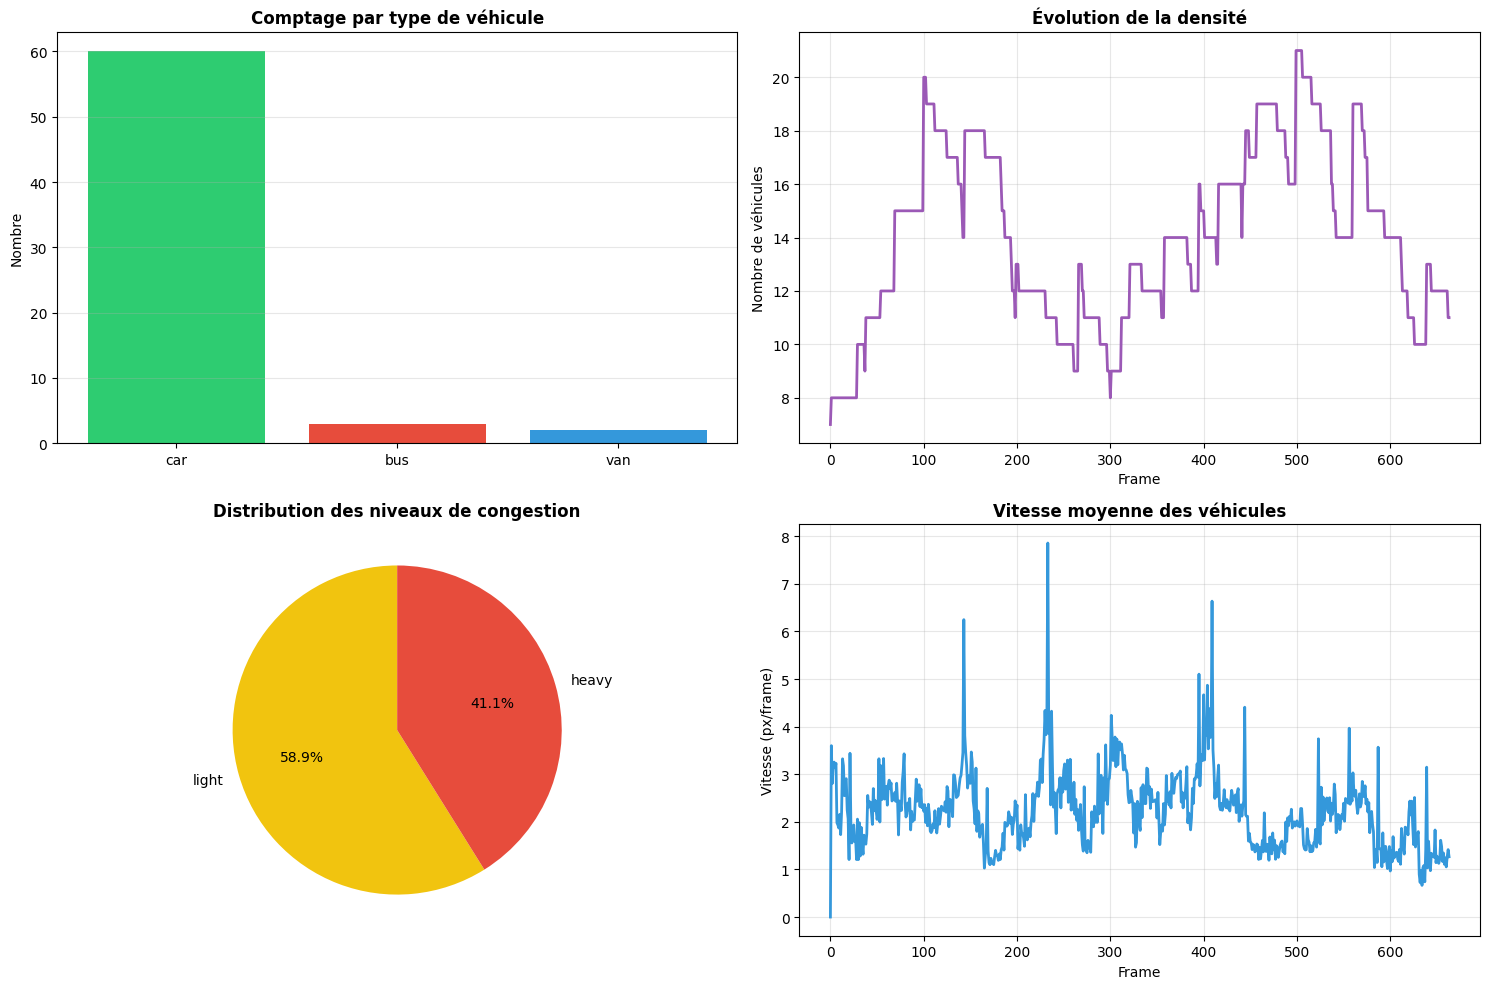

In [41]:
# Traiter la première vidéo comme exemple
if model is not None and video_files:
    test_video = video_files[0]
    output_video = OUTPUT_DIR / f"{test_video.stem}_analyzed.mp4"
    
    print(f"\n🎬 Traitement de: {test_video.name}")
    
    results = process_video_with_counting_and_congestion(
        video_path=test_video,
        model=model,
        conf_threshold=0.5,
        output_video_path=output_video,
        show_progress=True
    )
    
    if results:
        # Convertir en types sérialisables avant sauvegarde JSON
        results = convert_to_serializable(results)
        
        # Afficher résultats
        display_results(results)
        
        # Sauvegarder en JSON
        json_path = OUTPUT_DIR / f"{test_video.stem}_results.json"
        with open(json_path, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"✅ Résultats sauvegardés: {json_path}")
        
        # Visualisations
        plot_analysis(results)
else:
    print("❌ Modèle ou vidéos non disponibles")

### 8.3 Traiter toutes les vidéos (optionnel)

In [42]:
# Traiter toutes les vidéos
all_results = []

if model is not None and video_files:
    # Limiter à 3 vidéos pour le test (sinon peut être long)
    videos_to_process = video_files[:3]
    
    for video_path in videos_to_process:
        output_video = OUTPUT_DIR / f"{video_path.stem}_analyzed.mp4"
        
        results = process_video_with_counting_and_congestion(
            video_path=video_path,
            model=model,
            conf_threshold=0.5,
            output_video_path=output_video,
            show_progress=True
        )
        
        if results:
            # Convertir en types sérialisables
            results = convert_to_serializable(results)
            all_results.append(results)
            display_results(results)
    
    # Sauvegarder tous les résultats
    if all_results:
        combined_json = OUTPUT_DIR / 'all_results.json'
        with open(combined_json, 'w') as f:
            json.dump(all_results, f, indent=2)
        print(f"\n✅ {len(all_results)} vidéos traitées")
        print(f"✅ Résultats: {combined_json}")
else:
    print("❌ Modèle ou vidéos non disponibles")


📹 Vidéo: MVI_20011.avi
   960x540, 25 FPS, 664 frames


Processing: 100%|██████████| 664/664 [00:59<00:00, 11.19it/s]



📊 RÉSULTATS - MVI_20011.avi

📹 Vidéo:
  • FPS: 25
  • Total frames: 664
  • Durée: 26.6s

🚗 COMPTAGE VÉHICULES:
  • Voitures:  60
  • Bus:        3
  • Vans:       2
  • TOTAL:     65

🚦 CONGESTION:
  • Niveau: LIGHT
  • Densité moyenne: 11.8 véhicules/frame
  • Densité max: 13 véhicules/frame
  • Vitesse moyenne: 1.3 px/frame


📹 Vidéo: MVI_20012.avi
   960x540, 25 FPS, 936 frames


Processing: 100%|██████████| 936/936 [01:03<00:00, 14.71it/s]



📊 RÉSULTATS - MVI_20012.avi

📹 Vidéo:
  • FPS: 25
  • Total frames: 936
  • Durée: 37.4s

🚗 COMPTAGE VÉHICULES:
  • Voitures:  41
  • Bus:        3
  • Vans:       5
  • TOTAL:     49

🚦 CONGESTION:
  • Niveau: SPARSE
  • Densité moyenne: 1.2 véhicules/frame
  • Densité max: 2 véhicules/frame
  • Vitesse moyenne: 0.3 px/frame


📹 Vidéo: MVI_20032.avi
   960x540, 25 FPS, 437 frames


Processing: 100%|██████████| 437/437 [00:36<00:00, 11.86it/s]


📊 RÉSULTATS - MVI_20032.avi

📹 Vidéo:
  • FPS: 25
  • Total frames: 437
  • Durée: 17.5s

🚗 COMPTAGE VÉHICULES:
  • Voitures:  13
  • Bus:        0
  • Vans:       0
  • TOTAL:     13

🚦 CONGESTION:
  • Niveau: SPARSE
  • Densité moyenne: 4.0 véhicules/frame
  • Densité max: 5 véhicules/frame
  • Vitesse moyenne: 3.1 px/frame


✅ 3 vidéos traitées
✅ Résultats: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\results\vehicle_counting_congestion\all_results.json


## 9. Résumé global et comparaisons

In [43]:
# Résumé de toutes les vidéos
if all_results:
    print("\n" + "="*70)
    print("📈 RÉSUMÉ GLOBAL")
    print("="*70)
    
    total_vehicles = sum(r['total_vehicles'] for r in all_results)
    total_cars = sum(r['vehicle_counts']['car'] for r in all_results)
    total_buses = sum(r['vehicle_counts']['bus'] for r in all_results)
    total_vans = sum(r['vehicle_counts']['van'] for r in all_results)
    
    print(f"\n📹 Vidéos traitées: {len(all_results)}")
    print(f"\n🚗 TOTAL VÉHICULES: {total_vehicles}")
    print(f"  • Voitures: {total_cars} ({100*total_cars/total_vehicles:.1f}%)")
    print(f"  • Bus: {total_buses} ({100*total_buses/total_vehicles:.1f}%)")
    print(f"  • Vans: {total_vans} ({100*total_vans/total_vehicles:.1f}%)")
    
    # Congestion moyenne
    avg_densities = [r['congestion_stats']['avg_density'] for r in all_results]
    print(f"\n🚦 CONGESTION MOYENNE: {np.mean(avg_densities):.1f} véhicules/frame")
    
    # Tableau comparatif
    comparison_data = []
    for r in all_results:
        comparison_data.append({
            'Vidéo': r['video_name'][:30],
            'Total': r['total_vehicles'],
            'Cars': r['vehicle_counts']['car'],
            'Buses': r['vehicle_counts']['bus'],
            'Vans': r['vehicle_counts']['van'],
            'Congestion': r['congestion_stats']['congestion_level']
        })
    
    df = pd.DataFrame(comparison_data)
    print("\n" + df.to_string(index=False))
    print("\n" + "="*70)


📈 RÉSUMÉ GLOBAL

📹 Vidéos traitées: 3

🚗 TOTAL VÉHICULES: 127
  • Voitures: 114 (89.8%)
  • Bus: 6 (4.7%)
  • Vans: 7 (5.5%)

🚦 CONGESTION MOYENNE: 5.6 véhicules/frame

        Vidéo  Total  Cars  Buses  Vans Congestion
MVI_20011.avi     65    60      3     2      light
MVI_20012.avi     49    41      3     5     sparse
MVI_20032.avi     13    13      0     0     sparse



## 10. Export des résultats en CSV

In [44]:
# Export CSV détaillé
if all_results:
    # CSV des véhicules
    vehicle_data = []
    for r in all_results:
        for v in r['vehicle_details']:
            vehicle_data.append({
                'video': r['video_name'],
                'vehicle_id': int(v['id']),
                'class': v['class'],
                'first_frame': int(v['first_frame']),
                'last_frame': int(v['last_frame']),
                'duration': int(v['duration'])
            })
    
    if vehicle_data:
        vehicles_csv = OUTPUT_DIR / 'vehicles_details.csv'
        pd.DataFrame(vehicle_data).to_csv(vehicles_csv, index=False)
        print(f"✅ Détails véhicules: {vehicles_csv}")
    
    # CSV congestion par frame
    congestion_data = []
    for r in all_results:
        for c in r['congestion_history']:
            congestion_data.append({
                'video': r['video_name'],
                'frame': int(c['frame']),
                'num_vehicles': int(c['num_vehicles']),
                'avg_speed': float(c['avg_speed']),
                'congestion': c['congestion']
            })
    
    if congestion_data:
        congestion_csv = OUTPUT_DIR / 'congestion_history.csv'
        pd.DataFrame(congestion_data).to_csv(congestion_csv, index=False)
        print(f"✅ Historique congestion: {congestion_csv}")
    
    print(f"\n✅ Tous les résultats exportés dans: {OUTPUT_DIR}")

✅ Détails véhicules: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\results\vehicle_counting_congestion\vehicles_details.csv
✅ Historique congestion: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\results\vehicle_counting_congestion\congestion_history.csv

✅ Tous les résultats exportés dans: c:\Users\maxde\Desktop\Cours\ENTPE 3e année\Data Science\Introduction to Computer Vision\ICV_project\results\vehicle_counting_congestion


## 11. Conclusion

### Résultats obtenus:
1. ✅ **Car Counting**: Comptage précis par type sans double comptage
2. ✅ **Congestion Detection**: 4 niveaux (sparse, light, medium, heavy)
3. ✅ **Vidéos annotées**: Visualisation avec boîtes et IDs
4. ✅ **Exports**: JSON, CSV pour analyses ultérieures

### Métriques calculées:
- Nombre total de véhicules par type
- Densité moyenne et maximale
- Vitesse moyenne des véhicules
- Distribution temporelle de la congestion

### Fichiers générés:
- `videos.avi`: Vidéos annotées
- `*_results.json`: Résultats détaillés par vidéo
- `all_results.json`: Résultats combinés
- `vehicles_details.csv`: Détails de chaque véhicule
- `congestion_history.csv`: Historique frame par frame